Chargement des données pour PEP et KO...


[*********************100%***********************]  2 of 2 completed


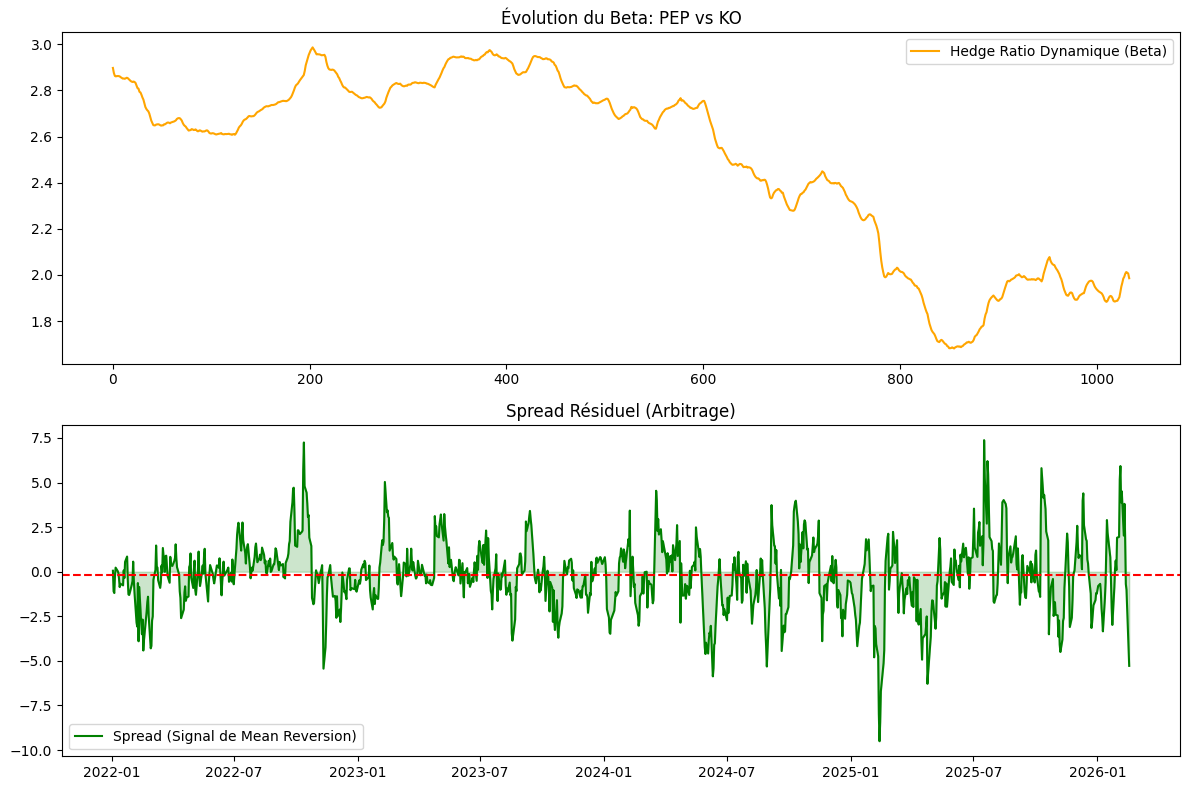

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from pykalman import KalmanFilter
import matplotlib.pyplot as plt

def run_kalman_pairs_trading(ticker_y="PEP", ticker_x="KO"):
    # 1. Récupération des données
    print(f"Chargement des données pour {ticker_y} et {ticker_x}...")
    data = yf.download([ticker_y, ticker_x], start="2022-01-01", auto_adjust=True)['Close']
    y, x = data[ticker_y], data[ticker_x]

    # 2. Configuration du Filtre de Kalman
    # On cherche à estimer y = beta * x + alpha
    obs_mat = np.vstack([x, np.ones(len(x))]).T[:, np.newaxis]
    kf = KalmanFilter(n_dim_obs=1, n_dim_state=2,
                      initial_state_mean=np.zeros(2),
                      transition_matrices=np.eye(2),
                      observation_matrices=obs_mat,
                      transition_covariance=1e-5 * np.eye(2),
                      observation_covariance=1.0)

    state_means, _ = kf.filter(y.values)
    beta, alpha = state_means[:, 0], state_means[:, 1]

    # 3. Calcul du spread (résidu)
    spread = y - (beta * x + alpha)
    
    # 4. Visualisation
    plt.figure(figsize=(12, 8))
    plt.subplot(211)
    plt.plot(beta, label="Hedge Ratio Dynamique (Beta)", color='orange')
    plt.title(f"Évolution du Beta: {ticker_y} vs {ticker_x}")
    plt.legend()
    
    plt.subplot(212)
    plt.plot(spread, label="Spread (Signal de Mean Reversion)", color='green')
    plt.axhline(spread.mean(), color='red', linestyle='--')
    plt.fill_between(spread.index, spread, alpha=0.2, color='green')
    plt.title("Spread Résiduel (Arbitrage)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return spread, beta

# Teste-le directement :
spread, beta = run_kalman_pairs_trading()